In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
cap = cv2.VideoCapture("data/videos/chaplin.mp4")

In [3]:
if(cap.isOpened() == False):
    print("Error opening video stream or file")

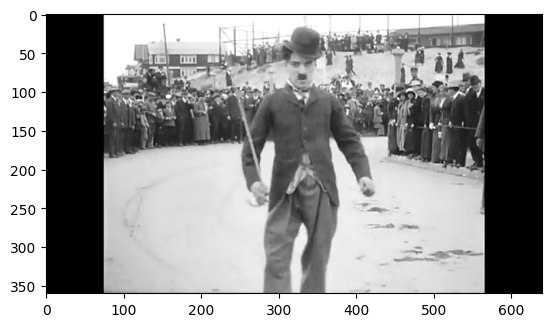

In [4]:
ret, frame = cap.read()
plt.imshow(frame[...,::-1])

In [ ]:
while(cap.isOpened()):
    ret, frame = cap.read()

    if ret == True:
        cv2.imshow("Video Output", frame)
        cv2.waitKey(5)
    else:
        break

: 

In [5]:
cap.get(3), cap.get(4), cap.get(5), cap.get(6)

(640.0, 360.0, 29.719556780471343, 875967080.0)

In [6]:
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
out = cv2.VideoWriter('outputChaplin.mp4',cv2.VideoWriter_fourcc('M','J','P','G'), 10, (frame_width,frame_height))

In [7]:
while(cap.isOpened()):
    ret, frame = cap.read()

    if ret == True:
        out.write(frame)
        cv2.waitKey(25)
    else:
        break

In [8]:
cap.release()
out.release()

### Keyboard as Input in Video

In [5]:
import cv2

# Open webcam
cap = cv2.VideoCapture(0)
k=0
while(True):
  # Read frame
    ret,frame = cap.read()
    # Identify if 'ESC' is pressed or not
    if(k==27):
        print("Pressed ESC")
        break
    # Identify if 'e' or 'E' is pressed
    if(k==101 or k==69):
        print("pressed e/E")
        cv2.putText(frame, "E is pressed, press Z or ESC", 
                    (100,180), cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (100,255,120), 3);
    # Identify if 'z' or 'Z' is pressed
    if(k==90 or k==122):
        print("pressed z/Z")
        cv2.putText(frame, "Z is pressed",
                    (100,180), cv2.FONT_HERSHEY_SIMPLEX, 
                    1, (100,255,120), 3)
    cv2.imshow("Image",frame)
    # Increase waitkey to show display properly
    k= cv2.waitKey(10000) & 0xFF

cap.release()
cv2.destroyAllWindows()

pressed e/E
pressed z/Z
Pressed ESC


### Mouse for annotation

In [9]:
import math

def drawCircle(action, x, y, flags, userdata):
    global center, circumference

    if action == cv2.EVENT_LBUTTONDOWN:
        center = [(x,y)]
    elif action == cv2.EVENT_LBUTTONUP:
        circumference = [(x,y)]
        radius = math.sqrt(math.pow(center[0][0] -circumference[0][0], 2) + 
                           math.pow(center[0][1] -circumference[0][1], 2))
        
    cv2.circle(source, center[0], int(radius), (0,0,255), thickness=2, lineType=cv2.LINE_AA)
    cv2.imshow("window", source)


In [ ]:
source = cv2.imread("data/images/sample.jpg", cv2.IMREAD_UNCHANGED)
dummy = source.copy()
cv2.namedWindow("window")
cv2.setMouseCallback("window", drawCircle)
k=0

while k != 27:
    cv2.imshow("window", source)
    cv2.putText(source, '''Choose the center and drag to draw circle, 
                Pressed ESC to exit and c to clear''', (10, 30), cv2.FONT_HERSHEY_TRIPLEX, 0.7, (255,255,255), 2);

    k = cv2.waitKey(20) & 0xFF

    if k ==99:
        source = dummy.copy()

cv2.destroyAllWindows()

### Assignment 02

In [4]:
import cv2



# create boundingbox as selected by the user
def createAndCropBoundingBox(event, x, y, flags, param):
    global ix, iy, croppingSize

    if event == cv2.EVENT_LBUTTONDOWN:
        ix, iy = x, y
    
    elif event == cv2.EVENT_LBUTTONUP:
        cv2.rectangle(img, (ix, iy), (x,y), (255,0,255), thickness=2, lineType=cv2.LINE_AA)
        cv2.imshow("Image", img)

        croppingSize = [(ix, iy), (x,y)]


# Read the required image
img = cv2.imread("data/images/sample.jpg", cv2.IMREAD_UNCHANGED)
dummy = img.copy()

# Create a namedWindow and se an event called Mouse Callback on that window
cv2.namedWindow("Image")
cv2.setMouseCallback("Image", createAndCropBoundingBox)

# Set key to 0
k=0
# initial setting
ix, iy = -1, -1
croppingSize = None

# till ESC is not pressed, run
while(k != 27):
    cv2.imshow("Image", img)
    cv2.putText(img, "Choose top left corner, and drag.?", (2, 493), cv2.FONT_HERSHEY_DUPLEX, 0.8, (200, 112, 50), 2, cv2.LINE_AA);

    # without this while loop will run infinitely and the image never appears
    k = cv2.waitKey(20) & 0xFF
    if croppingSize:
        x1, y1 = croppingSize[0]
        x2, y2 = croppingSize[1]

        cropped_img = dummy[y1:y2, x1:x2]
        cv2.imwrite("cropped_image.jpg", cropped_img)
        cv2.waitKey(1000)
        cv2.destroyAllWindows()
        break

cv2.destroyAllWindows()